# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/ANALYTICS/Colaboratory/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
season_mapping = {
    12:1, 1:1, 2:1,
    3:2, 4:2, 5:2,
    6:3, 7:3, 8:3, 9:3,
    10:4, 11:4
}

df['weather_season_india'] = df['month'].map(season_mapping)

In [5]:
df['weather_season_india'].tail(10)

,weather_season_india
datetime,
2012-12-19 14:00:00,1
2012-12-19 15:00:00,1
2012-12-19 16:00:00,1
2012-12-19 17:00:00,1
2012-12-19 18:00:00,1
2012-12-19 19:00:00,1
2012-12-19 20:00:00,1
2012-12-19 21:00:00,1
2012-12-19 22:00:00,1



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [6]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

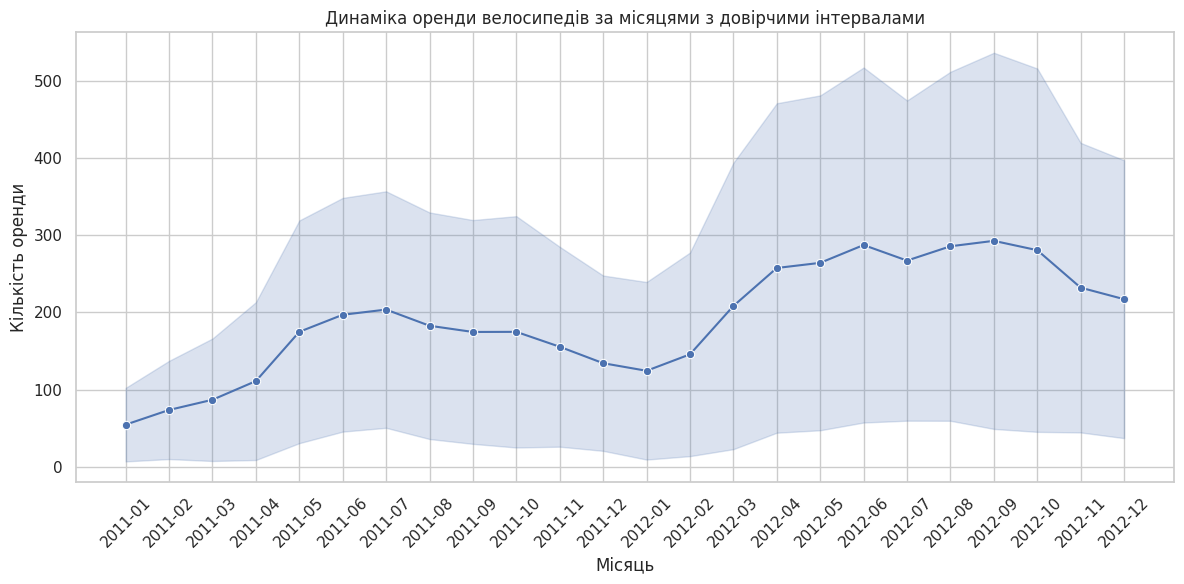

In [7]:
plt.figure(figsize = (12,6))
sns.lineplot(df, x ='month_year', y = 'count', errorbar = 'sd', marker = 'o')
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Найбільша невизначеність, згідно з нашим графіком, є в період орієнтовно з 2012-04 до 2012-10 — це видно по інтервалу відхилень в орендах»

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

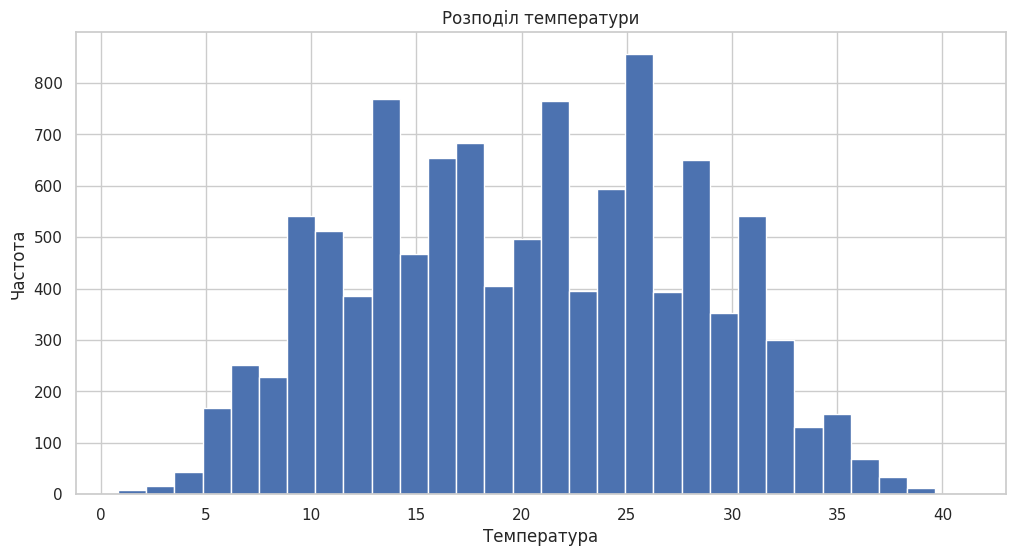

In [8]:
df['temp'].plot.hist(
    bins = 30,
    figsize = (12,6),
    title = 'Розподіл температури',
    xlabel = 'Температура',
    ylabel = 'Частота'
);

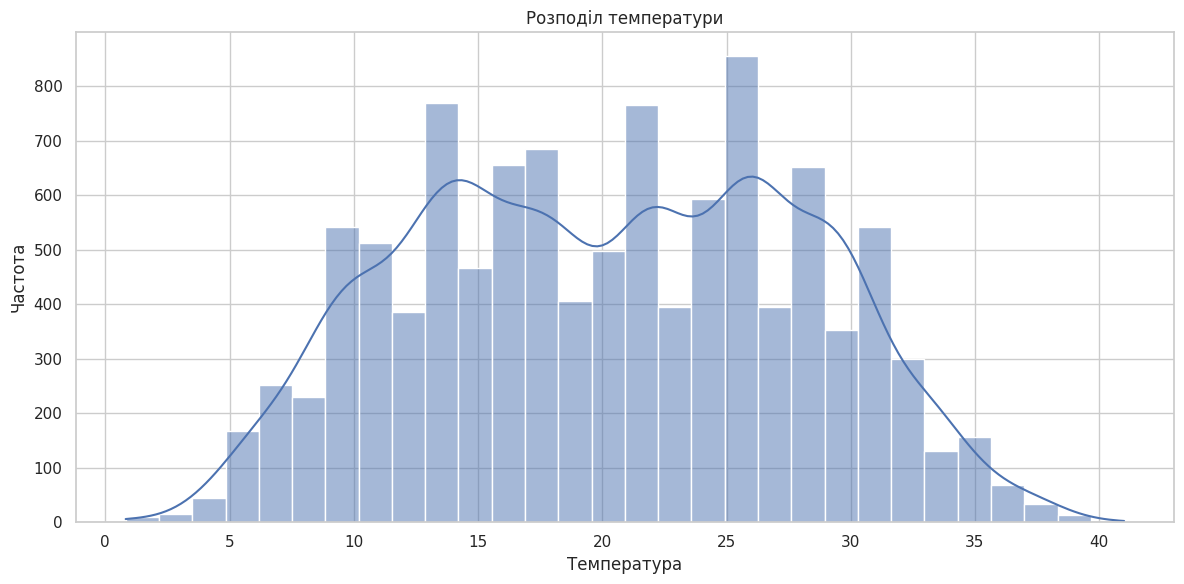

In [9]:
plt.figure(figsize = (12,6))
sns.histplot(df['temp'], bins = 30, kde = True),
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

1) Візуально відрізняється стилістикою - навіть без додаткових налаштувань графік на seaborn має сучасніший вигляд.

2) На мою думку ця лінія показує згладжену тенденцію розподілу даних - її піки демонструють, де зосереджені основні масиви даних.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [10]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_desc'] = df['weather'].map(weather_labels)

df['weather_desc'] = pd.Categorical(
    df['weather_desc'],
    categories=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    ordered=True
)

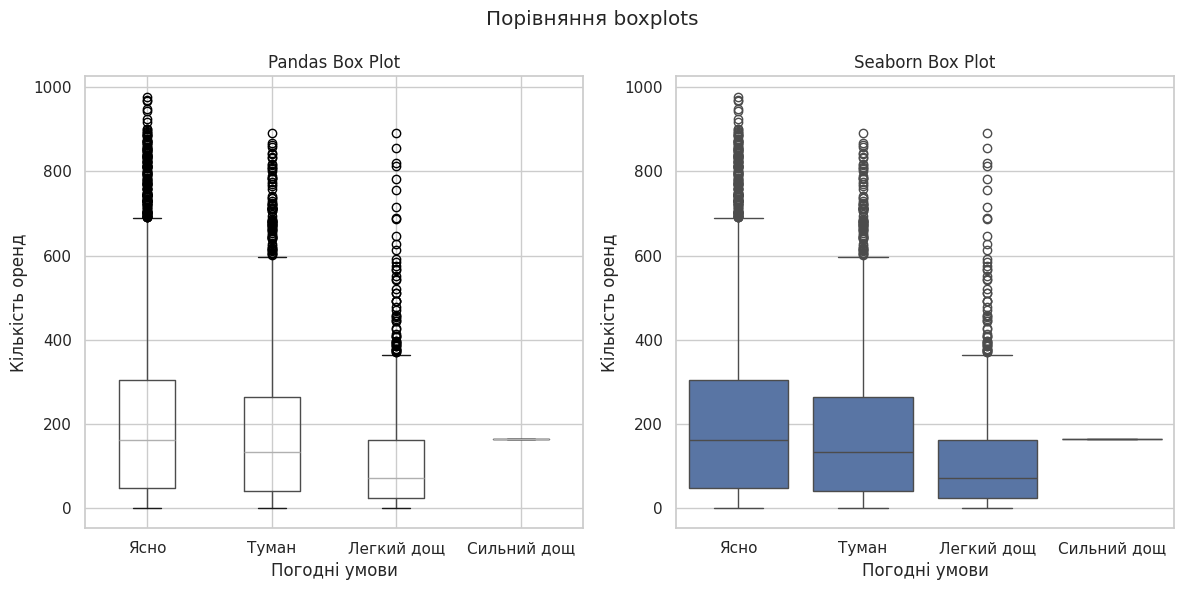

In [11]:
fig, ax = plt.subplots(1,2, figsize = (12,6))

df.boxplot(column = 'count', by = 'weather_desc', ax = ax[0])
ax[0].set_title('Pandas Box Plot')
ax[0].set_xlabel('Погодні умови')
ax[0].set_ylabel('Кількість оренд')

sns.boxplot(data = df, x = 'weather_desc', y = 'count', ax = ax[1])
ax[1].set_title('Seaborn Box Plot')
ax[1].set_xlabel('Погодні умови')
ax[1].set_ylabel('Кількість оренд')

plt.tight_layout()
plt.suptitle('Порівняння boxplots')
plt.show()

Візуально різнниця полягає в наявному форматуванні в seaborn та загальній його простоті в сприйнятті

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [12]:
corr_matrix = df[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()

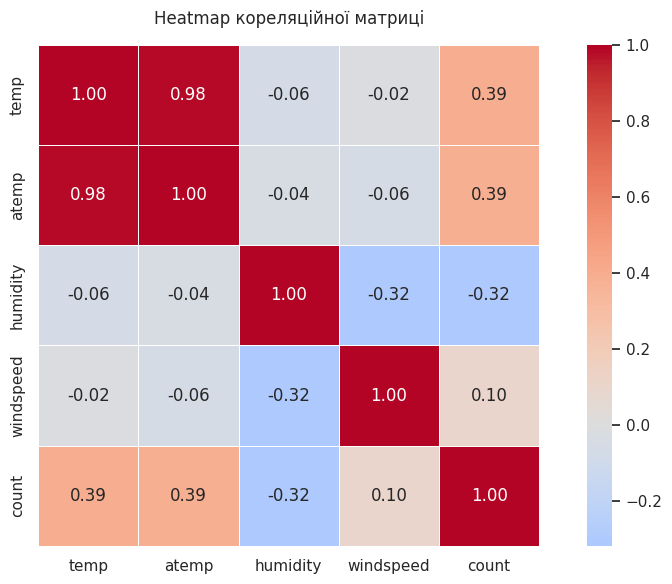

In [13]:
plt.figure(figsize = (10, 6))

sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', center = 0, square = True, fmt='.2f', linewidths=0.5)  #AI за деякі параметри підказав

plt.title('Heatmap кореляційної матриці', pad = 15)
plt.tight_layout()
plt.show()

1) Найсильніше корелюють із кількість оренди температура та відчуття температури.

2) Кореляція між temp та atemp практично дорівнює 1,0 (0,98) - адже це взаємопов'язані показники.

3) Найбільш негативну кореляцію мають показники вологості зі швидкістю вітру (-0.32), а також вологості з кількістю оренди (-0.32). Також слабку негативну кореляцію мають температура та відчутна температура із вологістю (-0.06 та -0.04) і швидкістю вітру (-0.02 та -0.06).

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


In [14]:
df['quarter'] = df.index.quarter

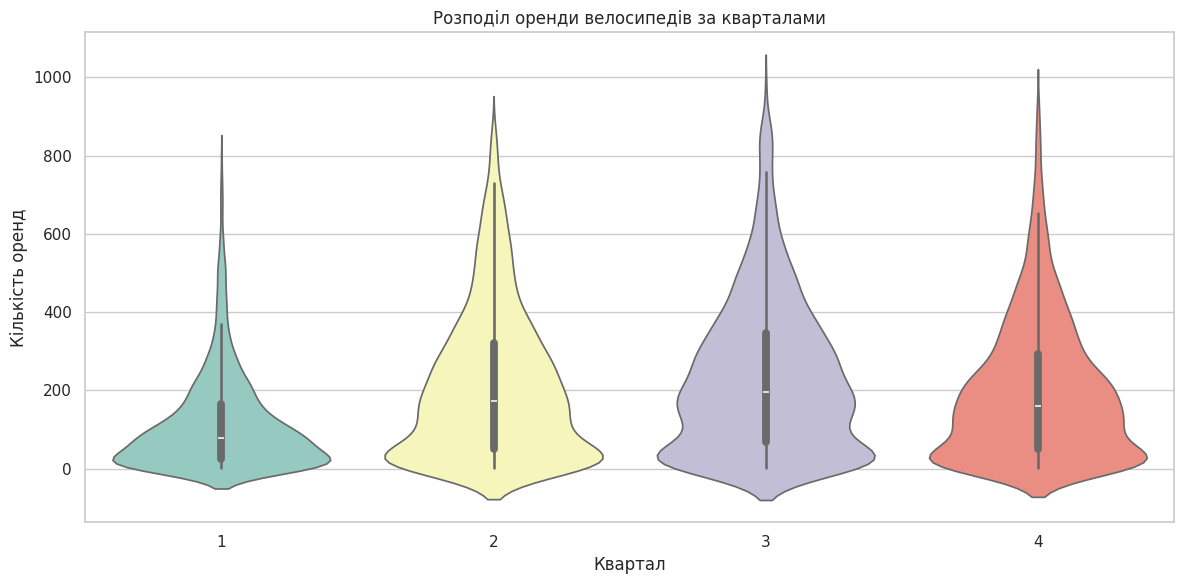

In [17]:
plt.figure(figsize = (12, 6))

sns.violinplot(data = df, x = 'quarter', y = 'count', palette = 'Set3', hue = 'quarter', legend = False)
plt.title('Розподіл оренди велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

1) Товщина розподілу показує щільність розподілу даних.

2) Найбільша варіабельність даних зосереджена в третьому кварталі - показник перевищує за 1000.

3) Перевага violin plot над box plot в тому, що останній показуж лише основні показники - медіану та квантилі, а violin plot ще показує щільність розподілу даних - як розширення, так і звуження.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

In [29]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'quarter']]

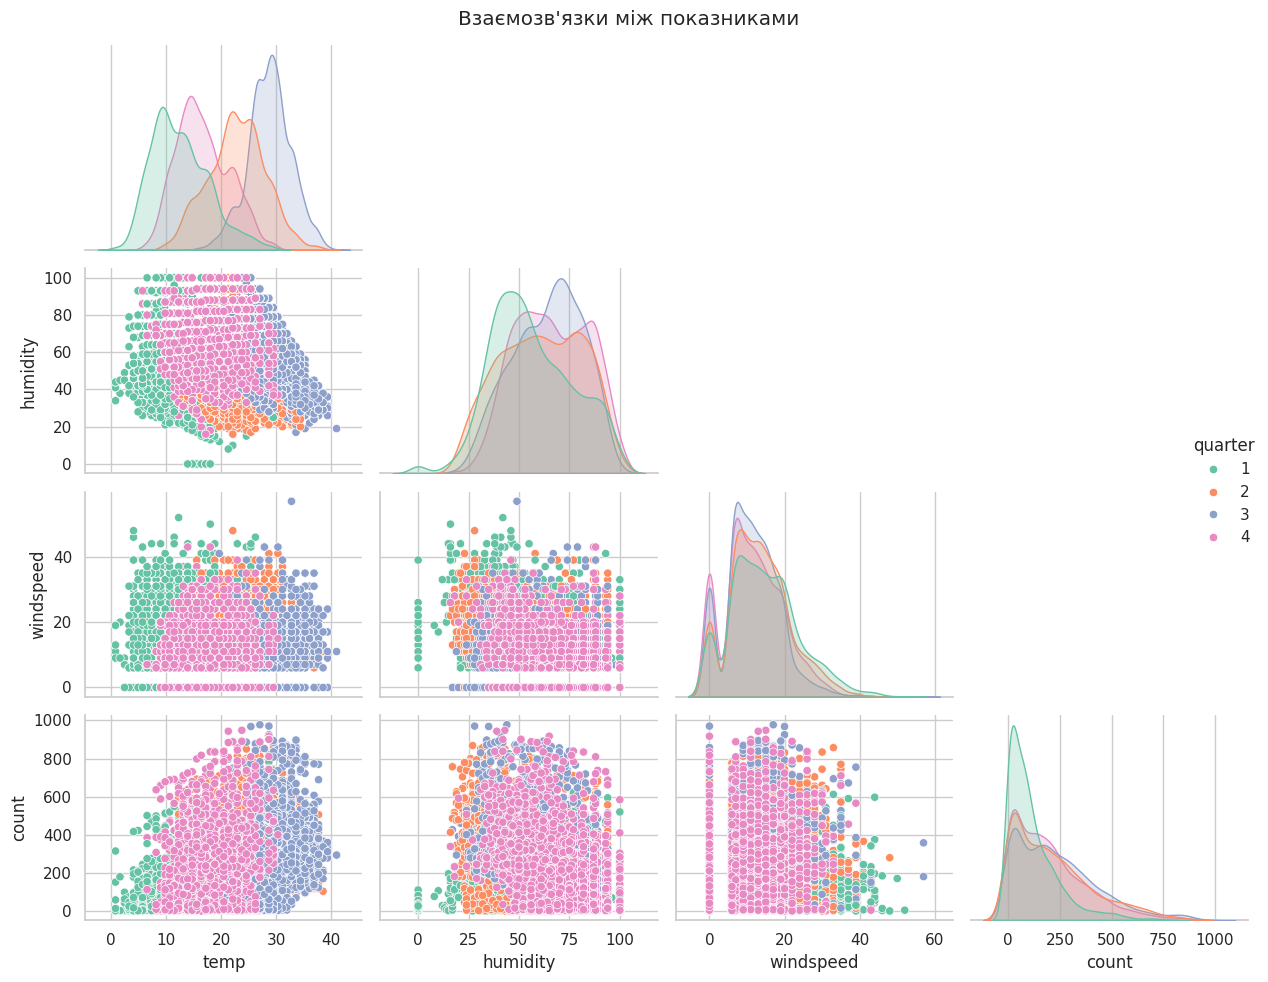

In [31]:
sns.pairplot(sample_df, height = 2.5, aspect = 1.2, hue = 'quarter', palette='Set2', corner=True) #AI дав підказки за деякі налаштування
plt.suptitle('Взаємозв\'язки між показниками')
plt.tight_layout()
plt.show()

1) Найсильніший лінійний зв'язок спостерігається між температурою та кількістю оренд - видно, що в тепліші квартали зростає і кількість оренд.

2) Найсильніше відрізняється температура. На першому графіку чітко видно, що горби сильно відхилені один від одного.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

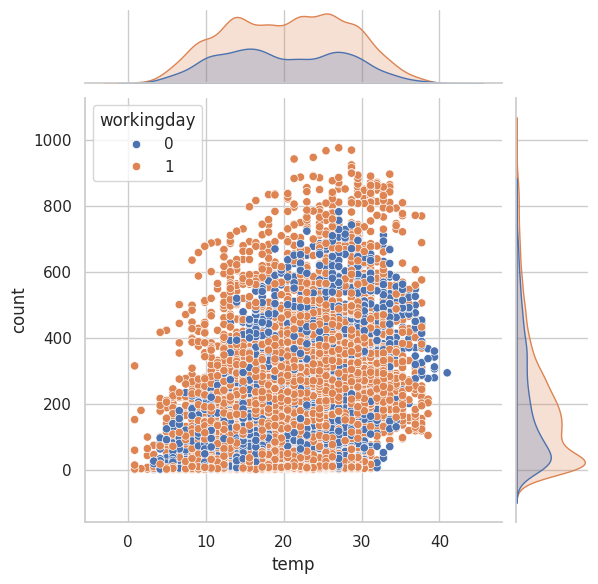

In [34]:
sns.jointplot(data = df, x = 'temp', y = 'count', hue = 'workingday');

1) Графіки по краях показують щільність того, як розподілені дані з температури та кількості оренд окремо в робочі та неробочі дні.

2) Більшість користувачів є в робочі дні - якщо дивитись, що на крайній графік, що на центральний. Але зі збільшенням температури дещо і збільшується кількість оренд у неробочий час.